## Применение однослойной НС с линейной функцией активации для прогнозирования временных рядов

Цель работы - изучить возможности однослойных НС в задачах прогнозирования временных рядов методом скользящего окна (авторегрессия)

### Подключение необходимых библиотек

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List

### Класс перцептрона для прогнозирования временных рядов

In [52]:
class Perceptron:
    def __init__(
        self,
        window_size: int = 4,
        learning_rate: float = 0.02,
                ):
        self.window_size = window_size
        self.weights = np.zeros(window_size + 1)
        self.learning_rate = learning_rate
        self.delta_history = []
        self.rmse_history = []
        self.weights_history = []
        self.predictions_history = []
        self.targets = None
        self.last_epoch = -1
    
    def get_net(self, X: np.ndarray) -> float:
        X_bias = np.concatenate([[1], X])
        return np.dot(self.weights, X_bias)
    
    def activate(self, net: float) -> float:
        return net
    
    def predict(self, X: np.ndarray) -> float:
        net = self.get_net(X)
        return self.activate(net)
    
    def predict_batch(self, X: np.ndarray) -> np.ndarray:
        return np.array([self.predict(x) for x in X])
    
    def train_step(self, X_i: np.ndarray, y: float):
        y_pred = self.predict(X_i)
        delta = y - y_pred
        X_bias = np.concatenate([[1], X_i])
        delta_weights = self.learning_rate * delta * X_bias
        self.weights += delta_weights
        return abs(delta)
    
    def prepare_training_data(self, X: np.ndarray) -> Tuple[np.array, np.array]:
        X_train = []
        y_train = []
        for i in range(len(X) - self.window_size):
            X_train.append(X[i:i+self.window_size])
            y_train.append(X[i+self.window_size])
        return np.array(X_train), np.array(y_train)
    
    def train(self, X: np.ndarray, max_epochs: int = 7000) -> List:
        X_train, y_train = self.prepare_training_data(X)
        self.targets = y_train.copy()
        for epoch in range(max_epochs):
            self.weights_history.append(self.weights.copy())
            y_pred = self.predict_batch(X_train)
            self.predictions_history.append(y_pred.copy())
            total_delta = 0
            squared_deltas = []
            for i in range(len(X_train)):
                delta = self.train_step(X_train[i], y_train[i])
                total_delta += delta
                squared_deltas.append(delta**2)
            rmse = np.sqrt(np.mean(squared_deltas))
            self.rmse_history.append(rmse)
            self.delta_history.append(total_delta)
            if rmse < 1e-4:
                self.last_epoch = epoch + 1
                print(f'Обучение завершено на эпохе {epoch + 1}')
                break
        else:
            self.last_epoch = max_epochs
            print(f'Достигнуто максимальное число эпох -> {max_epochs}')
            
        return self.delta_history
    
    def forecast(self, X: np.ndarray, n_steps: int) -> np.array:
        forecast = []
        current_series = X.tolist()
        for _ in range(n_steps):
            X_in = np.array(current_series[-self.window_size:])
            y_pred = self.predict(X_in)
            forecast.append(y_pred)
            current_series.append(y_pred)
        return np.array(forecast)
    
    def get_metrics(self, X_test: np.ndarray, y_test: np.ndarray) -> dict:
        y_preds = np.array([self.predict(x) for x in X_test])
        mse = np.mean((y_test - y_preds)**2)
        rmse = np.sqrt(mse)
        return {'MSE': mse, 'RMSE': rmse}
        
    def print_training_info(self, X: np.ndarray) -> None:
        print(f"\n{'='*50}")
        print(f'Информация о перцептроне для прогнозирования временных рядов')
        print(f'Размер окна -> {self.window_size}')
        print(f'Скорость обучения -> {self.learning_rate}')
        print(f'Количество весов -> {len(self.weights)}')
        print(f'Веса -> {self.weights}')
        if self.last_epoch > -1:
            print(f'Обучение завершено на эпохе -> {self.last_epoch}')
            print(f'Последнее значение RMSE -> {self.rmse_history[-1]:.6f}')
            print(f'Последнее значение суммарной ошибки -> {self.delta_history[-1]:.6f}')
        else:
            print(f'Обучение ещё не проводилось или не было успешно завершено')
        print(f"{'='*50}\n")
        
    def get_training_truth_table(self, X: np.ndarray) -> pd.DataFrame:
        X_train, y_train = self.prepare_training_data(X)
        df = pd.DataFrame(X_train, columns=[f'x{i}' for i in range(self.window_size)])
        df['target'] = self.targets
        df['predicted'] = self.predict_batch(X_train)
        df['error'] = df['target'] - df['predicted']
        df['abs_error'] = np.abs(df['error'])
        return df
    
    def get_weights_history(self) -> pd.DataFrame:
        if not self.weights_history:
            print('История весов пуста')
            return None
        columns = ['w0'] + [f'w{i}' for i in range(self.window_size)]
        df = pd.DataFrame(self.weights_history, columns=columns)
        df['epoch'] = range(1, len(df) + 1)
        df['E(epoch)'] = self.delta_history
        df['RMSE'] = self.rmse_history
        cols = ['epoch'] + columns + ['E(epoch)', 'RMSE']
        df = df[cols]
        return df

### Исходная функция

In [40]:
def func(t: float) -> float:
    return 0.5 * np.cos(0.5 * t) - np.sin(t)

def generate_series(a: float, b: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    t = np.linspace(a, b, n)
    values = func(t)
    return t, values

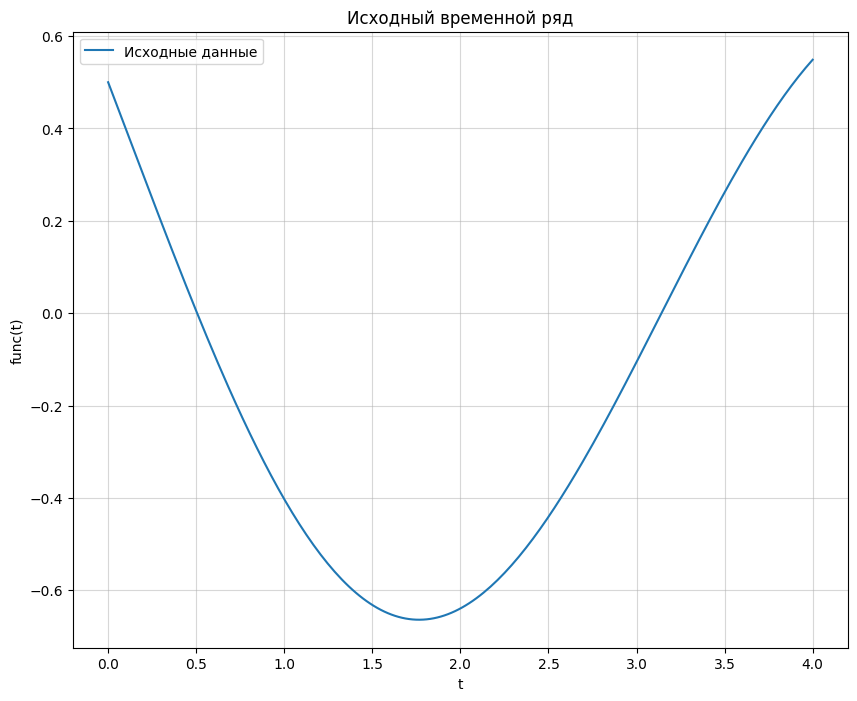

In [ ]:
a, b, n = 0, 4, 150

t_train, series = generate_series(a, b, n)

plt.figure(figsize=(10, 8))
plt.plot(t_train, series, label='Исходные данные')
plt.xlabel('t')
plt.ylabel('func(t)')
plt.title('Исходный временной ряд')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

### Обучение перцептрона

In [42]:
def wrap_table(table, name: str) -> None:
    print('='*50)
    print(name)
    print(table)
    print(f'{"="*50}\n')

In [53]:
perceptron = Perceptron()
perceptron.train(series)

forecast_steps = 150
t_future = np.linspace(b, b + (b-a), forecast_steps)
forecast = perceptron.forecast(series, n_steps = forecast_steps)
real_future = func(t_future)

perceptron.print_training_info(series)
training_table = perceptron.get_training_truth_table(series)
weights_history = perceptron.get_weights_history()

wrap_table(training_table, 'ТАБЛИЦА ОБУЧЕНИЯ НС')
wrap_table(weights_history, 'ИСТОРИЯ ВЕСОВ ПО ЭПОХАМ')

Обучение завершено на эпохе 1747

Информация о перцептроне для прогнозирования временных рядов
Размер окна -> 4
Скорость обучения -> 0.02
Количество весов -> 5
Веса -> [ 2.19267788e-04 -4.95710567e-01  2.76145304e-03  4.98947564e-01
  9.92630080e-01]
Обучение завершено на эпохе -> 1747
Последнее значение RMSE -> 0.000100
Последнее значение суммарной ошибки -> 0.017374

ТАБЛИЦА ОБУЧЕНИЯ НС
           x0        x1        x2        x3    target  predicted     error  \
0    0.500000  0.479876  0.459709  0.439508  0.419281   0.419328 -0.000048   
1    0.479876  0.459709  0.439508  0.419281  0.399035   0.399091 -0.000056   
2    0.459709  0.439508  0.419281  0.399035  0.378780   0.378844 -0.000064   
3    0.439508  0.419281  0.399035  0.378780  0.358523   0.358595 -0.000072   
4    0.419281  0.399035  0.378780  0.358523  0.338273   0.338352 -0.000079   
..        ...       ...       ...       ...       ...        ...       ...   
191  0.471497  0.482057  0.492369  0.502428  0.512227   0.5122

### Расчёт зависимости ошибки от нормы обучения, длины окна и количества эпох

In [44]:
learning_rates = np.linspace(0.001, 0.02, 15)
rmse_rate = []
for rate in learning_rates:
    temp_perceptron = Perceptron(learning_rate=rate)
    temp_perceptron.train(series)
    temp_forecast = temp_perceptron.forecast(series, forecast_steps)
    rmse_rate.append(np.mean((real_future - temp_forecast)**2))

window_sizes = np.arange(start=2, stop=11)
rmse_window = []
for window in window_sizes:
    temp_perceptron = Perceptron(window_size=window)
    temp_perceptron.train(series)
    temp_forecast = temp_perceptron.forecast(series, forecast_steps)
    rmse_window.append(np.mean((real_future - temp_forecast)**2))

epochs_list = np.arange(start=10, stop=7000, step=100)
rmse_epoch = []
for epoch in epochs_list:
    temp_perceptron = Perceptron()
    temp_perceptron.train(series, max_epochs=epoch)
    temp_forecast = temp_perceptron.forecast(series, forecast_steps)
    rmse_epoch.append(np.mean((real_future - temp_forecast)**2))

Достигнуто максимальное число эпох -> 7000
Достигнуто максимальное число эпох -> 7000
Достигнуто максимальное число эпох -> 7000
Обучение завершено на эпохе 5573
Обучение завершено на эпохе 4393
Обучение завершено на эпохе 3625
Обучение завершено на эпохе 3085
Обучение завершено на эпохе 2684
Обучение завершено на эпохе 2376
Обучение завершено на эпохе 2130
Обучение завершено на эпохе 1931
Обучение завершено на эпохе 1766
Обучение завершено на эпохе 1627
Обучение завершено на эпохе 1508
Обучение завершено на эпохе 1405
Достигнуто максимальное число эпох -> 7000
Обучение завершено на эпохе 3284
Обучение завершено на эпохе 1405
Обучение завершено на эпохе 762
Достигнуто максимальное число эпох -> 7000
Достигнуто максимальное число эпох -> 7000
Достигнуто максимальное число эпох -> 7000
Достигнуто максимальное число эпох -> 7000
Достигнуто максимальное число эпох -> 7000
Достигнуто максимальное число эпох -> 10
Достигнуто максимальное число эпох -> 110
Достигнуто максимальное число эпох -

### Графики

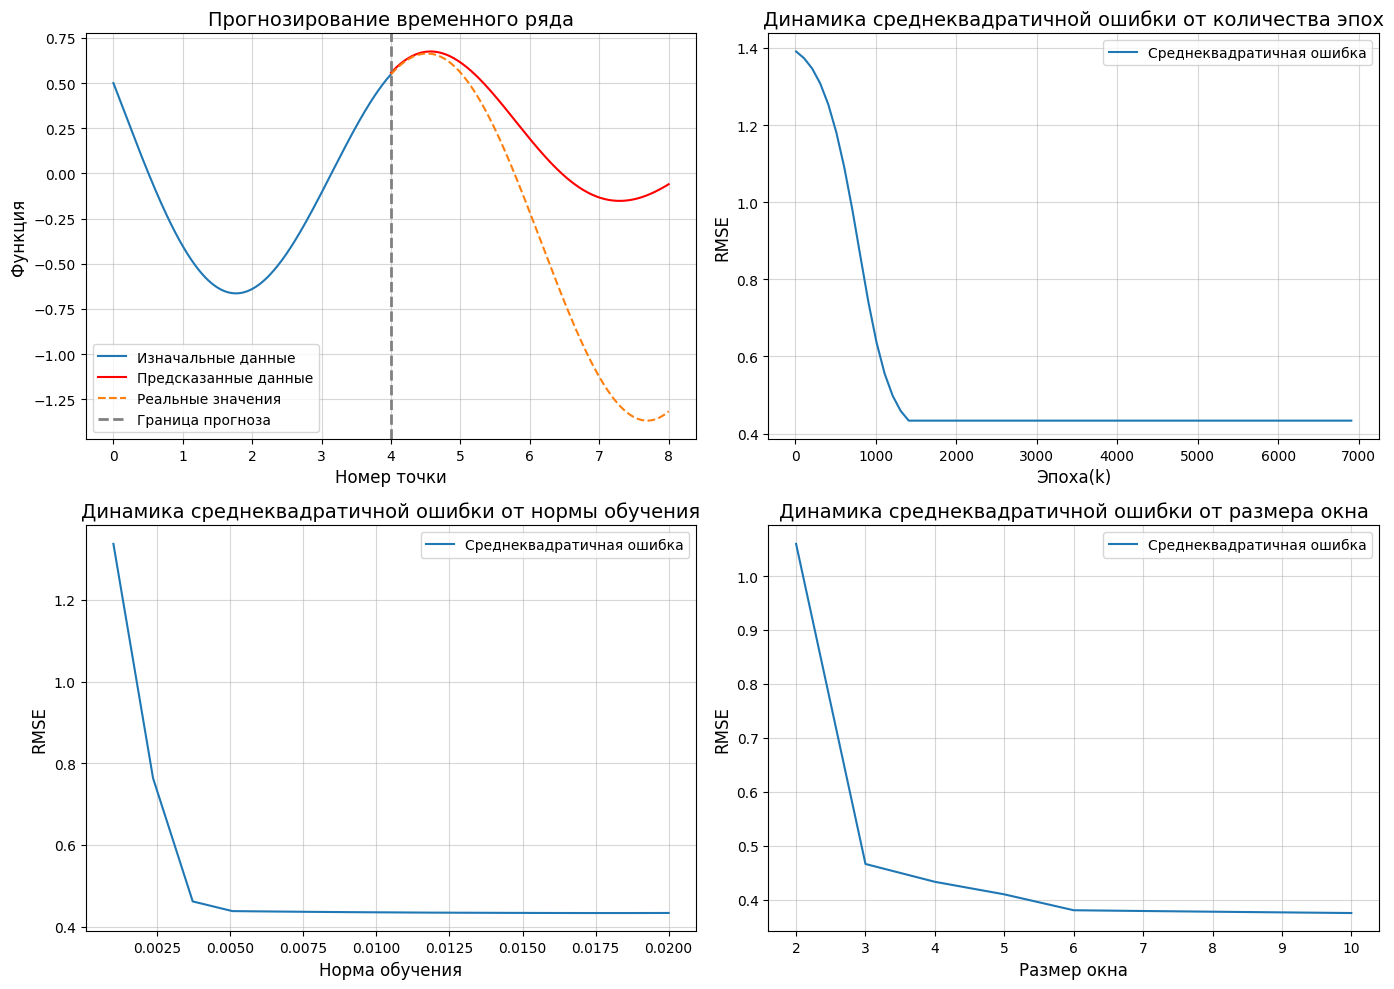

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.plot(t_train, series,  label='Изначальные данные')
ax1.plot(t_future, forecast,  label='Предсказанные данные', color='red')
ax1.plot(t_future, real_future, linestyle='--',  label='Реальные значения')
ax1.axvline(b, linestyle='--', color='grey', label='Граница прогноза', linewidth=2)
ax1.set_title('Прогнозирование временного ряда', fontsize=14)
ax1.set_xlabel('Номер точки', fontsize=12)
ax1.set_ylabel('Функция', fontsize=12)
ax1.legend(loc='lower left')
ax1.grid(True, alpha=0.5)

ax2 = axes[0, 1]
ax2.plot(epochs_list, rmse_epoch, label='Среднеквадратичная ошибка')
ax2.set_title('Динамика среднеквадратичной ошибки от количества эпох', fontsize=14)
ax2.set_xlabel('Эпоха(k)', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.5)

ax3 = axes[1, 0]
ax3.plot(learning_rates, rmse_rate, label='Среднеквадратичная ошибка')
ax3.set_title('Динамика среднеквадратичной ошибки от нормы обучения', fontsize=14)
ax3.set_xlabel('Норма обучения', fontsize=12)
ax3.set_ylabel('RMSE', fontsize=12)
ax3.legend()
ax3.grid(True, alpha=0.5)

ax4 = axes[1, 1]
ax4.plot(window_sizes, rmse_window, label='Среднеквадратичная ошибка')
ax4.set_title('Динамика среднеквадратичной ошибки от размера окна', fontsize=14)
ax4.set_xlabel('Размер окна', fontsize=12)
ax4.set_ylabel('RMSE', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.5)



plt.tight_layout()
plt.show()
